## 1. Training an autoencoder as a 2D feature generator and displaying CIFAR10 dataset's features.

### Import Necessary Libraries

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Dense, Flatten, Reshape, Conv2DTranspose, GlobalAveragePooling2D

## Load and Preprocess Datasets

In [2]:
(trainX, trainY), (testX, testY) = cifar10.load_data()

trainX = trainX.astype('float32') / 255.
testX = testX.astype('float32') / 255.

trainY_flat = trainY.flatten()
testY_flat = testY.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print('trainX shape:', trainX.shape)
print(trainX.shape[0], 'train samples')
print(testX.shape[0], 'test samples')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
trainX shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


### Building the Autoencodder Model

In [3]:
LATENT_DIM = 2

input_img = Input(shape=(32, 32, 3))

x = Conv2D(32, (3, 3), activation='relu', padding='same', strides=2)(input_img) # 16x16
x = Conv2D(64, (3, 3), activation='relu', padding='same', strides=2)(x) # 8x8
x = Conv2D(128, (3, 3), activation='relu', padding='same', strides=2)(x) # 4x4

shape_before_flattening = tf.keras.backend.int_shape(x)
x = Flatten()(x)
latent_vector = Dense(LATENT_DIM, name='latent_space')(x)

encoder = Model(input_img, latent_vector, name='encoder')
encoder.summary()

latent_input = Input(shape=(LATENT_DIM,))

x = Dense(np.prod(shape_before_flattening[1:]), activation='relu')(latent_input)
x = Reshape(shape_before_flattening[1:])(x)

x = Conv2DTranspose(128, (3, 3), activation='relu', padding='same', strides=2)(x) # 8x8
x = Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=2)(x) # 16x16
x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=2)(x) # 32x32

decoded_output = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

decoder = Model(latent_input, decoded_output, name='decoder')
decoder.summary()

autoencoder_input = Input(shape=(32, 32, 3), name='autoencoder_input')
encoded_img = encoder(autoencoder_input)
decoded_img = decoder(encoded_img)

autoencoder = Model(autoencoder_input, decoded_img, name='autoencoder')
autoencoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,346 (380.26 KB)

 Trainable params: 97,346 (380.26 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │        97,346 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 32, 32, 3)      │       246,851 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344,197 (1.31 MB)

 Trainable params: 344,197 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

### Compile and train the Autoencoder

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - loss: 0.0465 - val_loss: 0.0372
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0373 - val_loss: 0.0369
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0369 - val_loss: 0.0368
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0366 - val_loss: 0.0366
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0367 - val_loss: 0.0366
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0365 - val_loss: 0.0365
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0365 - val_loss: 0.0364
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0364 - val_loss: 0.0364
Epoch 9/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0365 - val_loss: 0.0365
Epoch 10/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0366 - val_loss: 0.0364
Epoch 11/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0365 - val_loss: 0.0365
Epoch 12/25
391/391 ━━━━━━━━━━━━━━━━━━━

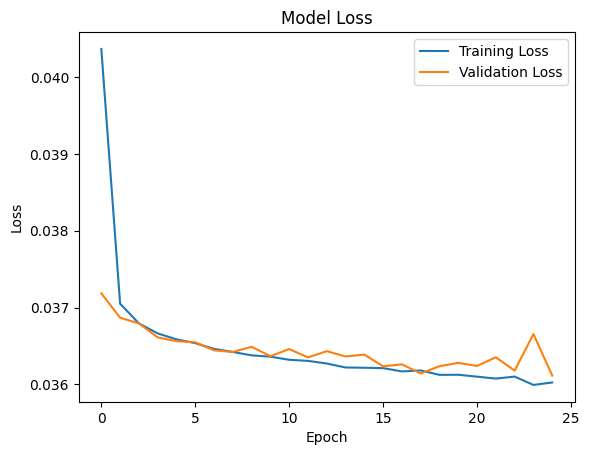

In [4]:
autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(
    trainX, trainX,
    epochs=25,
    batch_size=128,
    shuffle=True,
    validation_data=(testX, testX)
)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

### Visualization Reconstructed Image

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


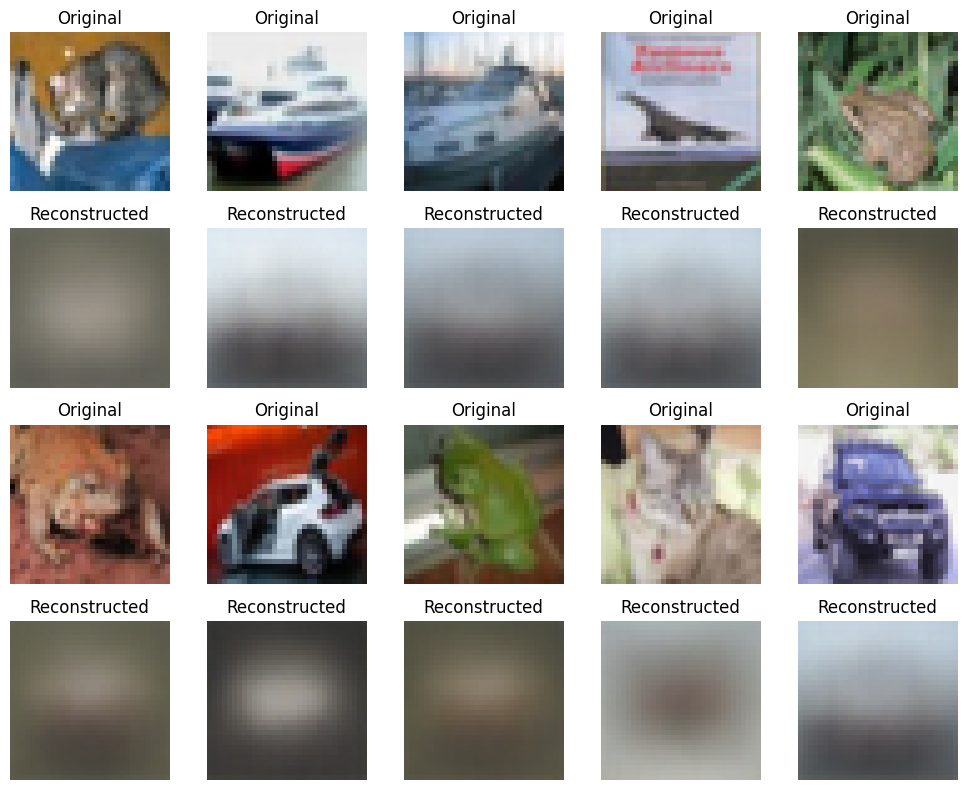

In [15]:
reconstructed_imgs = autoencoder.predict(testX)
n = 10
cols = 5
rows = 4
plt.figure(figsize=(10, 8))
for i in range(n):
    col = i % 5

    ax = plt.subplot(rows, cols, col + 1 + (0 if i < 5 else 2) * cols)
    plt.imshow(testX[i])
    plt.title("Original")
    ax.axis('off')

    ax = plt.subplot(rows, cols, col + 1 + (1 if i < 5 else 3) * cols)
    plt.imshow(reconstructed_imgs[i])
    plt.title("Reconstructed")
    ax.axis('off')

plt.tight_layout()
plt.show()

### Generation and displaying 2D features

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


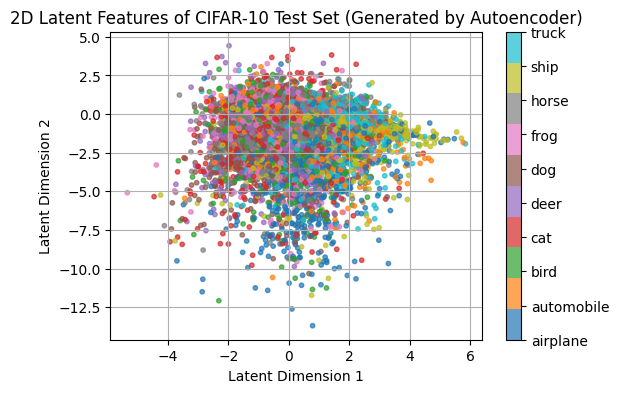

In [6]:
latent_features = encoder.predict(testX)

plt.figure(figsize=(6, 4))
scatter = plt.scatter(latent_features[:, 0], latent_features[:, 1], c=testY_flat, alpha=0.7, s=10, cmap='tab10')

cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(class_names)
plt.title('2D Latent Features of CIFAR-10 Test Set (Generated by Autoencoder)')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True)
plt.show()

## 2. Comparing autoencoder generated features with features extracted by a pre-trained CNN and reduced by dimension reduction techniques like PCA, t-SNE.

### Load VGG16 and extract high dimensional features

In [7]:
vgg16_base = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

print("Setting layer trainability...")
for i, layer in enumerate(vgg16_base.layers):
    if i < len(vgg16_base.layers) - 10:
        layer.trainable = False
    else:
        layer.trainable = True
    print(f"Layer {layer.name}: Trainable = {layer.trainable}")

vgg16_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Setting layer trainability...
Layer input_layer_2: Trainable = False
Layer block1_conv1: Trainable = False
Layer block1_conv2: Trainable = False
Layer block1_pool: Trainable = False
Layer block2_conv1: Trainable = False
Layer block2_conv2: Trainable = False
Layer block2_pool: Trainable = False
Layer block3_conv1: Trainable = False
Layer block3_conv2: Trainable = False
Layer block3_conv3: Trainable = True
Layer block3_pool: Trainable = True
Layer block4_conv1: Trainable = True
Layer block4_conv2: Trainable = True
Layer block4_conv3: Trainable = True
Layer block4_pool: Trainable = True
Layer block5_conv1: Trainable = True
Layer block5_conv2: Trainable = True
Layer block5_conv3: Trainable = True
Layer block5_pool: Trainable = True


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 13,569,280 (51.76 MB)

 Non-trainable params: 1,145,408 (4.37 MB)

### Model creation and fine tuning the model

In [8]:
inputs = tf.keras.Input(shape=(32, 32, 3))
x = vgg16_base(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(10)(x)
fine_tune_model = tf.keras.Model(inputs, outputs)

fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

fine_tune_model.summary()

(trainX, trainY), (testX, testY) = cifar10.load_data()
trainX = trainX.astype('float32') / 255.
testX = testX.astype('float32') / 255.
testY_flat = testY.flatten()

print("\nStarting fine-tuning...")
history_finetune = fine_tune_model.fit(
    trainX, trainY,
    epochs=10,
    batch_size=64,
    validation_data=(testX, testY)
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,818 (56.15 MB)

 Trainable params: 13,574,410 (51.78 MB)

 Non-trainable params: 1,145,408 (4.37 MB)


Starting fine-tuning...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.5262 - loss: 1.3466 - val_accuracy: 0.7187 - val_loss: 0.7907
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.7500 - loss: 0.7051 - val_accuracy: 0.7393 - val_loss: 0.7568
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.7910 - loss: 0.5899 - val_accuracy: 0.7718 - val_loss: 0.6596
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.8266 - loss: 0.4984 - val_accuracy: 0.7820 - val_loss: 0.6308
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.8498 - loss: 0.4297 - val_accuracy: 0.7935 - val_loss: 0.6020
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.8693 - loss: 0.3740 - val_accuracy: 0.7951 - val_loss: 0.6036
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.8905 - loss: 0.3234 - val_accuracy: 0.8024 - val_loss: 0.5938
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy:

### Apply PCA and t-SNE for dimensional reduction

In [9]:
tuned_vgg_layer = fine_tune_model.get_layer('vgg16')

print("Extracting fine-tuned features using the updated layer...")
vgg_features_tuned = tuned_vgg_layer.predict(testX)

vgg_features_tuned_flat = vgg_features_tuned.reshape(vgg_features_tuned.shape[0], -1)
print("Shape of fine-tuned features:", vgg_features_tuned_flat.shape)

print("\nApplying PCA to reduce dimensions to 2...")
pca_tuned = PCA(n_components=2)
pca_features_tuned = pca_tuned.fit_transform(vgg_features_tuned_flat)
print("PCA features shape:", pca_features_tuned.shape)

print("\nApplying t-SNE on all 10,000 samples. This may take a while...")
tsne_tuned = TSNE(n_components=2, verbose=1, perplexity=40, max_iter=500, random_state=42)
tsne_features_tuned = tsne_tuned.fit_transform(vgg_features_tuned_flat)
print("t-SNE features shape:", tsne_features_tuned.shape)

Extracting fine-tuned features using the updated layer...
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Shape of fine-tuned features: (10000, 512)

Applying PCA to reduce dimensions to 2...
PCA features shape: (10000, 2)

Applying t-SNE on all 10,000 samples. This may take a while...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.004s...
[t-SNE] Computed neighbors for 10000 samples in 4.485s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabiliti

### visualize and compare all three feature set

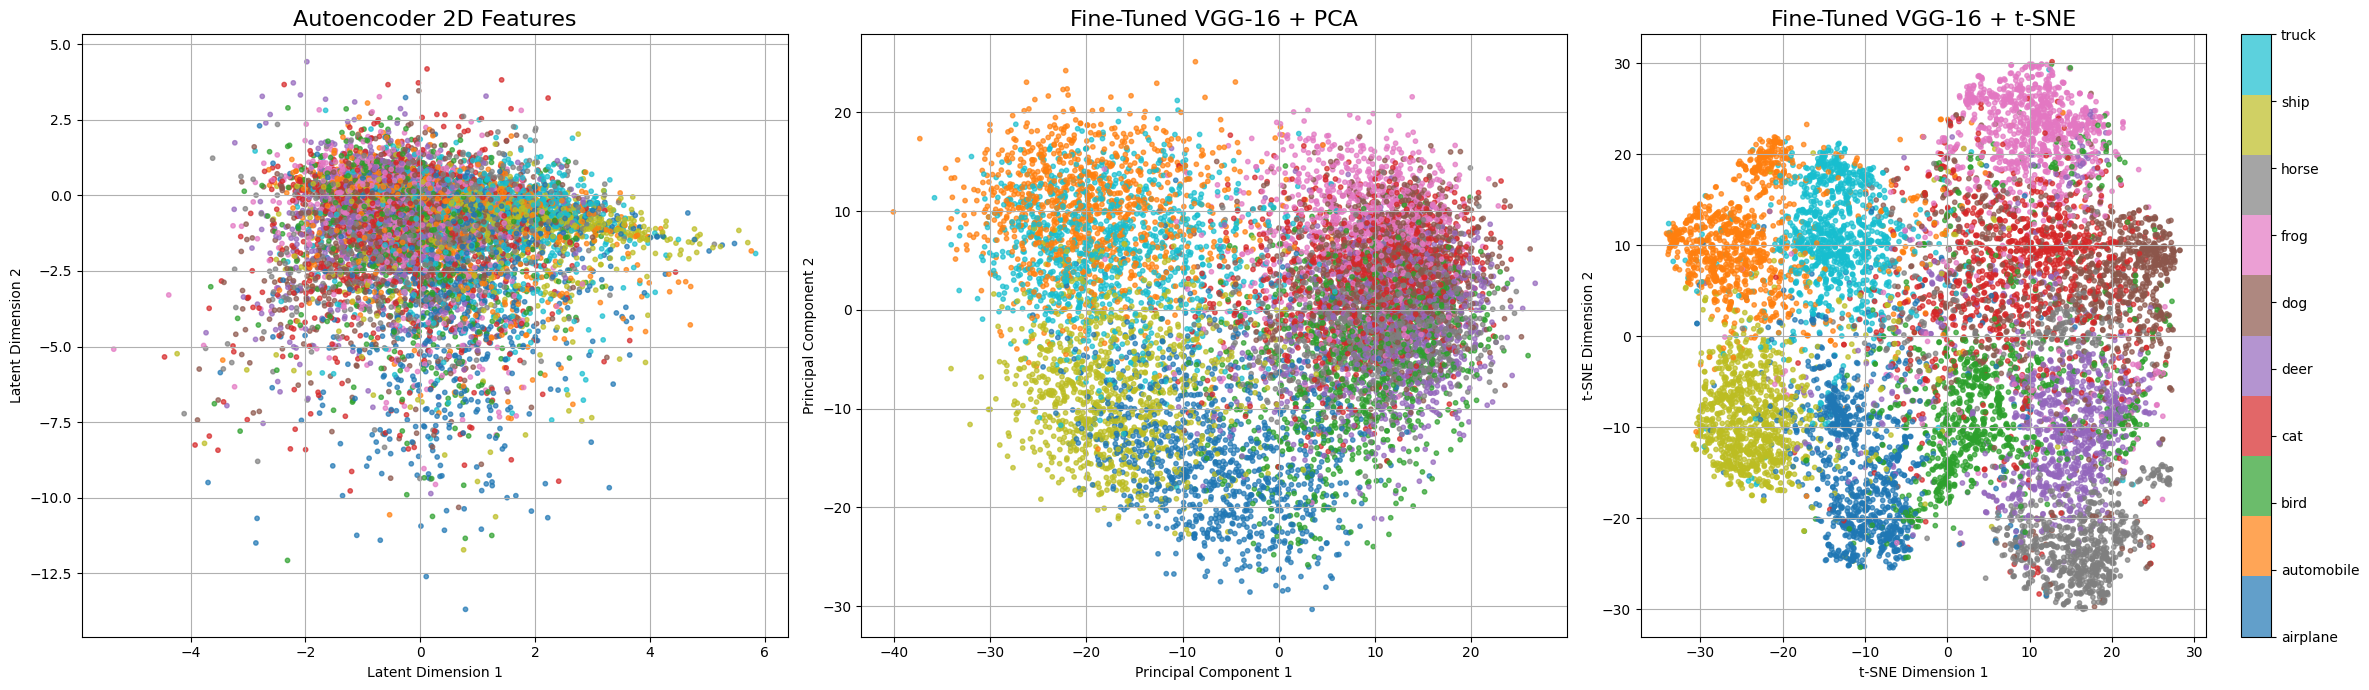

In [10]:
plt.figure(figsize=(24, 7))

plt.subplot(1, 3, 1)
plt.scatter(latent_features[:, 0], latent_features[:, 1], c=testY_flat,
            alpha=0.7, s=10, cmap='tab10')
plt.title('Autoencoder 2D Features', fontsize=16)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.scatter(pca_features_tuned[:, 0], pca_features_tuned[:, 1], c=testY_flat,
            alpha=0.7, s=10, cmap='tab10')
plt.title('Fine-Tuned VGG-16 + PCA', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

ax3 = plt.subplot(1, 3, 3)
scatter = ax3.scatter(tsne_features_tuned[:, 0], tsne_features_tuned[:, 1], c=testY_flat, alpha=0.7, s=10, cmap='tab10')
plt.title('Fine-Tuned VGG-16 + t-SNE', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)

cbar = plt.colorbar(scatter, ax=ax3, ticks=range(10))
cbar.ax.set_yticklabels(class_names)

plt.tight_layout()
plt.show()